In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad

In [12]:
# loading split PCA dataframes
adatas = []

splits = ["split_10", "split_20", "split_25", "split_33"]

for s in splits:
    adata = ad.read_h5ad(f"../data/pcScores_{s}.h5ad")
    adatas.append(adata)


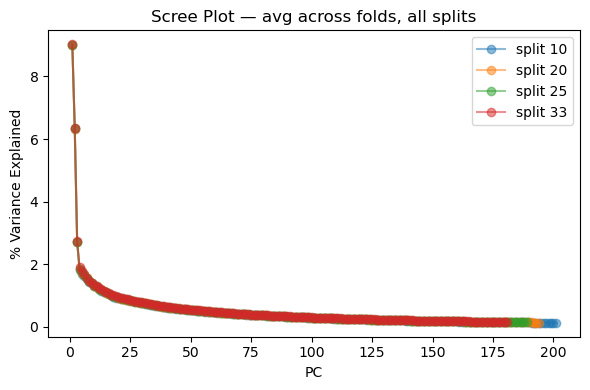

In [20]:
# scree plot — average % variance explained per PC across folds, overlaid per split
# uses training individuals only (split col == 0)
# folds with fewer PCs are NaN-padded before averaging

fig, ax = plt.subplots(figsize=(6, 4))

for adata, split in zip(adatas, splits):
    fold_keys = sorted([k for k in adata.obsm.keys() if k.startswith("X_pca_fold_")])

    # getting pc scores for each fold in split
    fold_variances = []
    for key in fold_keys:
        scores = adata.obsm[key]
        # dropping split indicator column
        pc_scores = scores[:, :-1]
        is_train  = scores[:, -1] == 0
        train_pcs = pc_scores[is_train]
        fold_variances.append(np.var(train_pcs, axis=0))

    # padding shorter folds with NaN then averaging
    max_k  = max(len(v) for v in fold_variances)
    padded = np.full((len(fold_variances), max_k), np.nan)
    for i, v in enumerate(fold_variances):
        padded[i, :len(v)] = v

    # averaging PC scores across folds per split and getting variance explained by all PCs
    avg_var = np.nanmean(padded, axis=0)
    explainedVar = avg_var / np.nansum(avg_var) * 100

    # plotting avg PC scores per cell
    ax.plot(range(1, len(explainedVar) + 1), explainedVar, "o-", label=split.replace("_", " "), alpha=0.5)

ax.set_xlabel("PC")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree Plot — avg across folds, all splits")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# PC1 mean per region across splits — using fold 1 PC scores
# Africa should stay negative, others positive across all splits

regions = sorted(adatas[0].obs['geo_region_of_origin'].unique())

print(f"{'Region':<25}" + "".join(f"{s:>12}" for s in splits))
print("-" * 73)

for region in regions:
    row = f"{region:<25}"
    for adata in adatas:
        mask = (adata.obs['geo_region_of_origin'] == region).values
        pc1  = adata.obsm['X_pca_fold_1'][mask, 0]
        row += f"{pc1.mean():>12.2f}"
    print(row)

Region                       split_10    split_20    split_25    split_33
-------------------------------------------------------------------------
AFRICA                         -34.67      -34.65      -34.63      -34.58
AMERICA                         13.44       13.44       13.71       13.87
CENTRAL_SOUTH_ASIA              10.27       10.16       10.14       10.19
EAST_ASIA                       11.87       12.16       12.19       12.02
EUROPE                          14.27       14.06       13.93       13.96
MIDDLE_EAST                      4.31        4.21        4.15        4.19
OCEANIA                          2.26        2.35        2.43        2.15


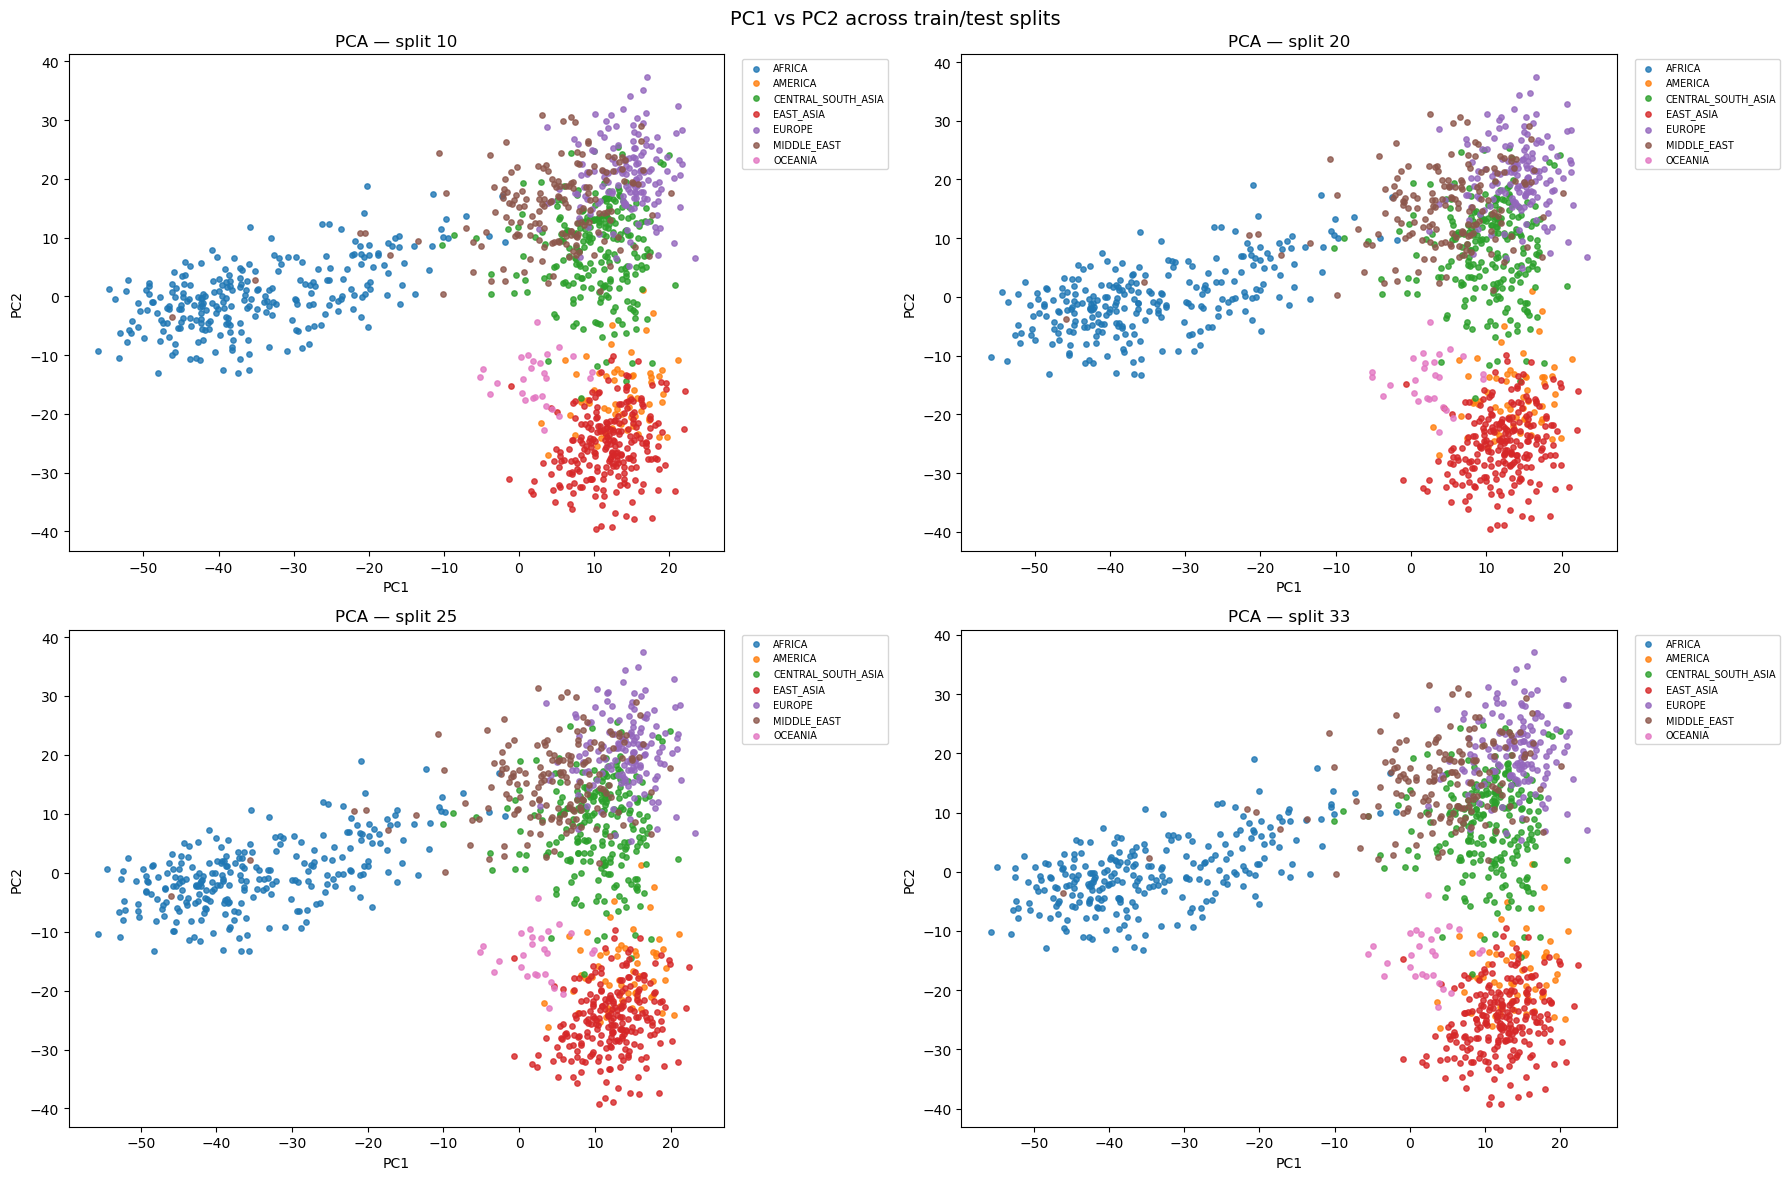

In [15]:
# PC1 vs PC2 — one per split, using fold 1 PC scores
# clusters should remain stable across splits

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, adata, split in zip(axes.flat, adatas, splits):
    pc_scores = adata.obsm['X_pca_fold_1'][:, :-1]
    labels = adata.obs['geo_region_of_origin'].values
    for region in sorted(np.unique(labels)):
        mask = labels == region
        ax.scatter(pc_scores[mask, 0], pc_scores[mask, 1], label = region, s = 15, alpha = 0.8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"PCA — {split.replace('_', ' ')}")
    ax.legend(fontsize = 7, bbox_to_anchor = (1.02, 1), loc = "upper left")

plt.suptitle("PC1 vs PC2 across train/test splits", fontsize = 14)
plt.tight_layout()
plt.show()

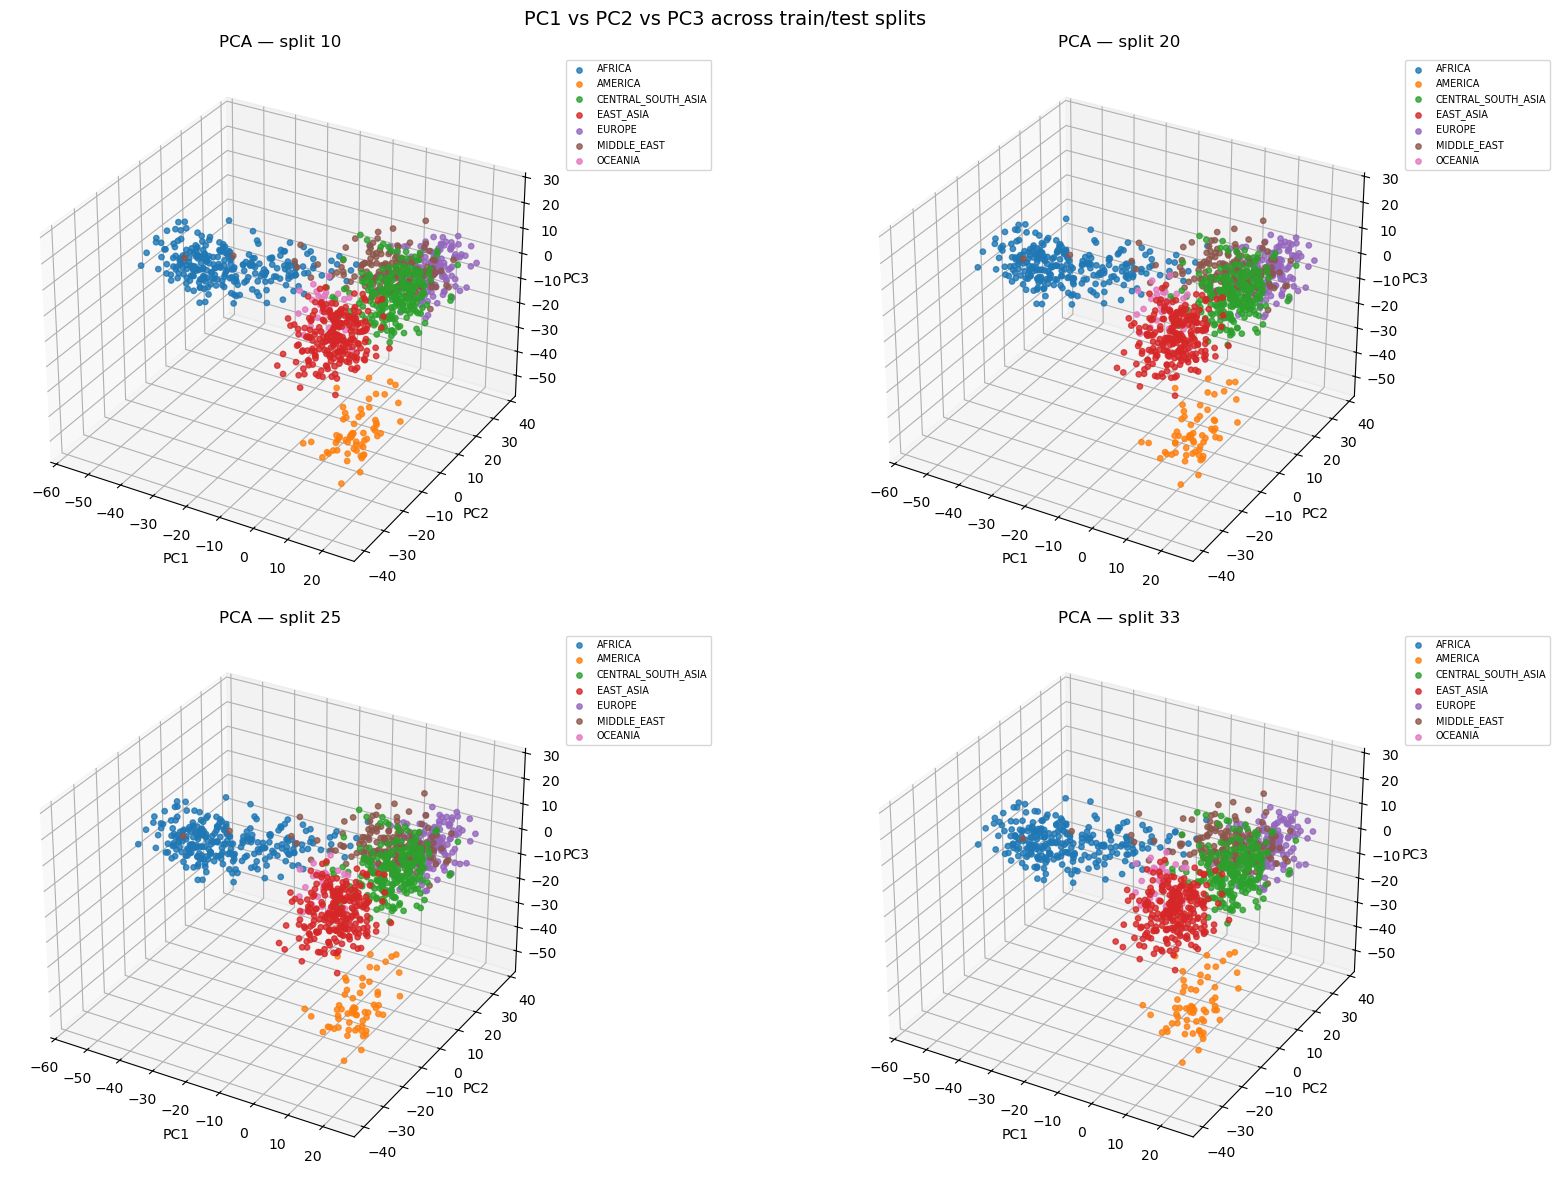

In [16]:
# 3D PCA — 2x2 subplots, one per split, using fold 1 PC scores

fig = plt.figure(figsize=(18, 12))

for i, (adata, split) in enumerate(zip(adatas, splits)):
    pc_scores = adata.obsm['X_pca_fold_1'][:, :-1]
    labels = adata.obs['geo_region_of_origin'].values
    ax3d = fig.add_subplot(2, 2, i + 1, projection="3d")
    for region in sorted(np.unique(labels)):
        mask = labels == region
        ax3d.scatter(pc_scores[mask, 0], pc_scores[mask, 1], pc_scores[mask, 2], label=region, s=15, alpha=0.8)
    ax3d.set_xlabel("PC1")
    ax3d.set_ylabel("PC2")
    ax3d.set_zlabel("PC3")
    ax3d.set_title(f"PCA — {split.replace('_', ' ')}")
    ax3d.legend(fontsize = 7, bbox_to_anchor = (1.02, 1), loc = "upper left")

plt.suptitle("PC1 vs PC2 vs PC3 across train/test splits", fontsize = 14)
plt.tight_layout()
plt.show()

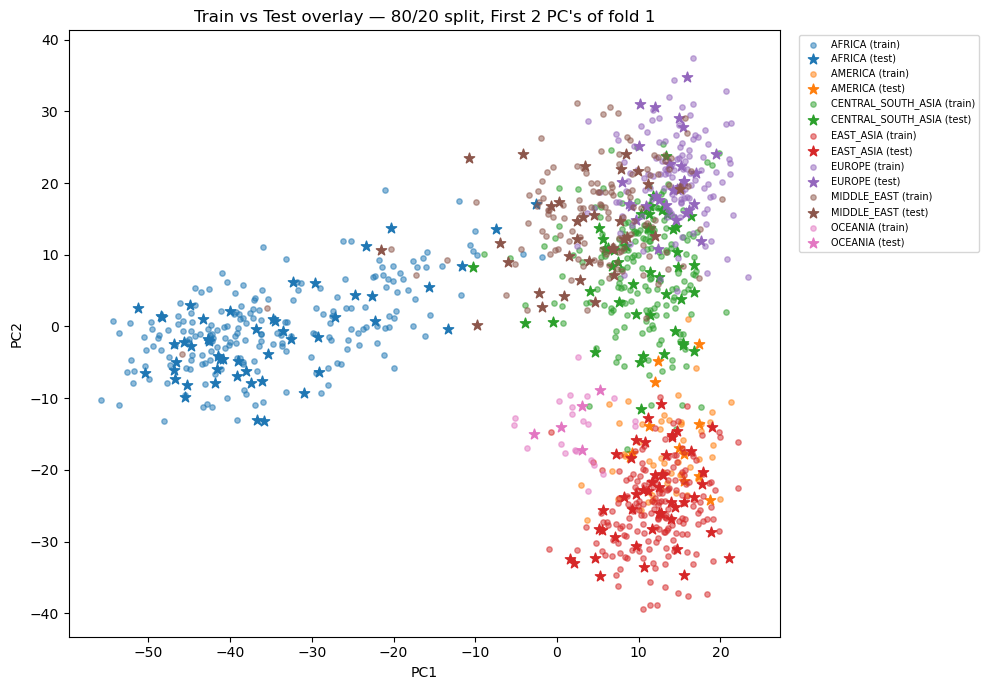

In [17]:
# train vs test overlay for 80/20 split, fold 1 (first 2 PCs)
# test points as stars on top of train points
# checks test samples fall within training clusters

adata     = adatas[1]   # split_20
pc_scores = adata.obsm['X_pca_fold_1'][:, :-1]
split_col = adata.obsm['X_pca_fold_1'][:, -1]   # 0 = train, 1 = test
labels    = adata.obs['geo_region_of_origin'].values
regions   = sorted(np.unique(labels))
colors    = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 7))

for i, region in enumerate(regions):
    mask_train = (labels == region) & (split_col == 0)
    mask_test  = (labels == region) & (split_col == 1)
    ax.scatter(pc_scores[mask_train, 0], pc_scores[mask_train, 1],
               color=colors[i], s=15, alpha=0.5, label=f"{region} (train)")
    ax.scatter(pc_scores[mask_test,  0], pc_scores[mask_test,  1],
               color=colors[i], s=60, alpha=1.0, marker="*", label=f"{region} (test)")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Train vs Test overlay — 80/20 split, First 2 PC's of fold 1")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

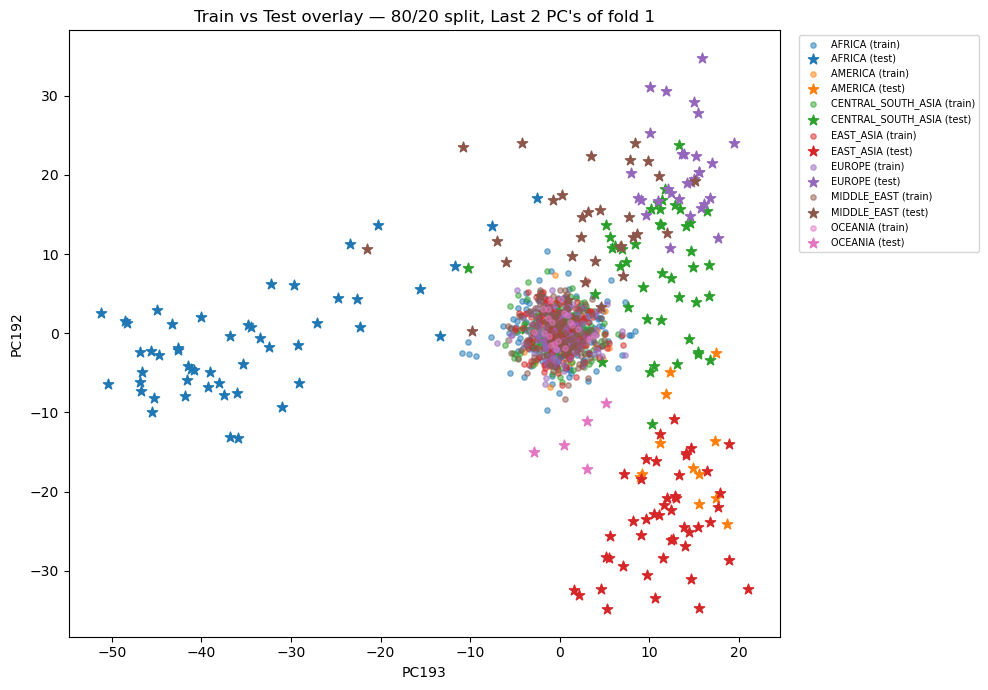

In [18]:
# train vs test overlay for 80/20 split, fold 1 (last 2 PCs)
# test points as stars on top of train points
# checks test samples fall within training clusters

adata     = adatas[1]   # split_20
pc_scores = adata.obsm['X_pca_fold_1'][:, :-1]
split_col = adata.obsm['X_pca_fold_1'][:, -1]   # 0 = train, 1 = test
labels    = adata.obs['geo_region_of_origin'].values
regions   = sorted(np.unique(labels))
colors    = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 7))

for i, region in enumerate(regions):
    mask_train = (labels == region) & (split_col == 0)
    mask_test  = (labels == region) & (split_col == 1)
    ax.scatter(pc_scores[mask_train, -2], pc_scores[mask_train, -1],
               color=colors[i], s=15, alpha=0.5, label=f"{region} (train)")
    ax.scatter(pc_scores[mask_test,  0], pc_scores[mask_test,  1],
               color=colors[i], s=60, alpha=1.0, marker="*", label=f"{region} (test)")

PC1 = len(pc_scores[1])
PC2 = len(pc_scores[1]) - 1

ax.set_xlabel(f"PC{PC1}")
ax.set_ylabel(f"PC{PC2}")
ax.set_title("Train vs Test overlay — 80/20 split, Last 2 PC's of fold 1")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

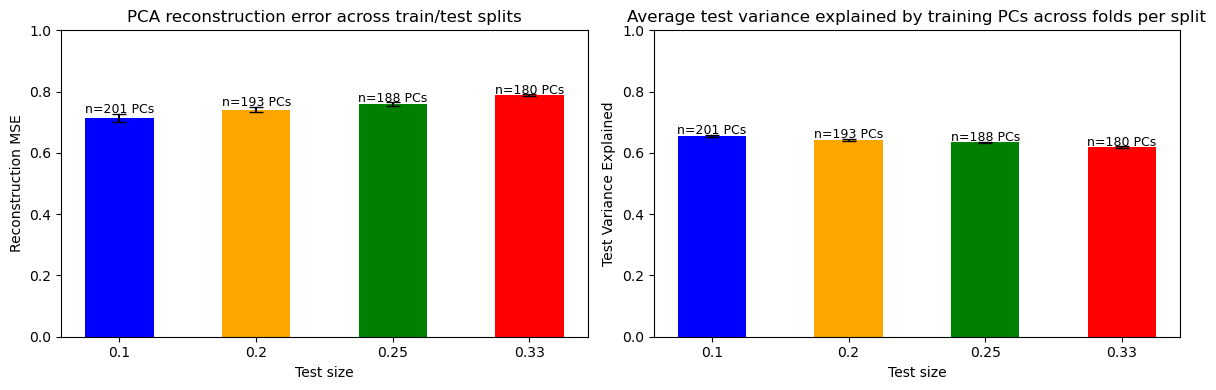

In [21]:
# reconstruction error and test variance explained across train/test splits
# error bars show std across folds

cvResults = pd.read_csv("../data/pcaCV_results.csv")

split_colors = ["blue", "orange", "green", "red"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# reconstruction error bar per split chart
ax1.bar(cvResults["test_size"].astype(str), cvResults["avg_reconError"],
        yerr=cvResults["std_reconError"], capsize=5, color=split_colors, width=0.5)
ax1.set_xlabel("Test size")
ax1.set_ylabel("Reconstruction MSE")
ax1.set_ylim([0, 1])
ax1.set_title("Average reconstruction error across train/test splits")

for i, row in cvResults.iterrows():
    ax1.text(i, row["avg_reconError"] + row["std_reconError"] + 0.002,
             f'n={int(row["avg_nComponents"])} PCs', ha="center", fontsize=9)

# test variance explained by training PCs per split chart
ax2.bar(cvResults["test_size"].astype(str), cvResults["avg_testVarExplained"],
        yerr=cvResults["std_testVarExplained"], capsize=5, color=split_colors, width=0.5)
ax2.set_xlabel("Test size")
ax2.set_ylabel("Test Variance Explained")
ax2.set_ylim([0, 1])
ax2.set_title("Average test variance explained by training PCs across folds per split")

for i, row in cvResults.iterrows():
    ax2.text(i, row["avg_testVarExplained"] + row["std_testVarExplained"] + 0.002,
             f'n={int(row["avg_nComponents"])} PCs', ha="center", fontsize=9)

plt.tight_layout()
plt.show()